In [1]:
# ESTA ES LA FORMA CORRECTA
import jax 
from jax import config
# Habilitar 64-bit float precision
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax, random, jit, vmap
from jax import tree_util
from functools import partial
from jax.scipy.stats import norm
from jax.example_libraries import optimizers
from jax.example_libraries.stax import Dense, Relu, serial
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import matplotlib.gridspec as gridspec

In [2]:
n = 6 # número de partículas
dim = 2 # dimensiones del espacio (2D)

i, j = np.triu_indices(n, k=1) # índices para calcular interacciones únicas entre partículas (i < j)
q = jnp.array([1, 1, 1, -1, -1, -1])   # cargas de las partículas (3 positivas, 3 negativas)

In [3]:
def energy_fun(
    x, n, dim, q,
    k_trap=1.0, k_coul=1.0,
    lj_eps=0.15, lj_sigma=0.14, lj_soft=0.10,
    use_wca=True,
    a_coul=0.10
):
    X = jnp.reshape(x, (n, dim))
    dX = X[:, None, :] - X[None, :, :]
    rij2 = jnp.sum(dX[i, j]**2, axis=-1)

    # Coulomb suavizado
    r_coul = jnp.sqrt(rij2 + a_coul**2)
    qq = q[i] * q[j]
    V_coul = jnp.sum(k_coul * qq / r_coul)

    # LJ/WCA suavizado
    r_eff = jnp.sqrt(rij2 + lj_soft**2)
    sr = lj_sigma / r_eff
    sr6 = sr**6
    V_lj_pair = 4.0 * lj_eps * (sr6**2 - sr6)

    if use_wca:
        r_c = (2.0 ** (1.0 / 6.0)) * lj_sigma
        V_lj_pair = jnp.where(r_eff < r_c, V_lj_pair + lj_eps, 0.0)

    V_lj = jnp.sum(V_lj_pair)

    V_ext = k_trap * jnp.sum(X**2)
    return V_ext + V_coul + V_lj

In [4]:
def pair_distance_stats(x, n, dim, lj_soft):
    X = jnp.reshape(x, (-1, n, dim))
    dX = X[:, :, None, :] - X[:, None, :, :]
    rij2 = jnp.sum(dX**2, axis=-1)
    iu = np.triu_indices(n, k=1)

    r = jnp.sqrt(rij2[:, iu[0], iu[1]])
    r_eff = jnp.sqrt(rij2[:, iu[0], iu[1]] + lj_soft**2)

    return jnp.min(r), jnp.min(r_eff), jnp.median(r), jnp.mean(r < 0.05), jnp.mean(r < 0.10)

In [5]:
def clip_grads(grads, max_norm=1.0, eps=1e-8):
    leaves = tree_util.tree_leaves(grads)
    gnorm = jnp.sqrt(sum([jnp.sum(jnp.square(g)) for g in leaves]))
    scale = jnp.minimum(1.0, max_norm / (gnorm + eps))
    grads = tree_util.tree_map(lambda g: g * scale, grads)
    return grads, gnorm, scale

In [6]:
def energy_wrapped(x, n, dim):
    return energy_fun(
        x, n, dim, q=q,
        k_trap=1.0, k_coul=1.0,
        lj_eps=0.15,
        lj_sigma=0.14,
        lj_soft=0.10,
        use_wca=True,
        a_coul=0.10,
    )

# Modelo generativo #


In [7]:

def layer (transform): # Crear una capa de flujo normalizante a partir de una función de transformación dada
    def init_fun(rng, input_dim): # Inicializar los parámetros de la capa y definir las funciones directa e inversa
        cutoff = input_dim // 2
        perm = jnp.arange(input_dim)[::-1]
        params, trans_fun = transform(rng, cutoff, 2 * (input_dim - cutoff))

        def direct_fun(params, inputs): # Transformación directa, aplicando la permutación a las entradas
            lower, upper = inputs[:, :cutoff], inputs[:, cutoff:]

            st = 0.02 * trans_fun(params, lower)  
            log_weight, bias = jnp.split(st, 2 , axis =-1)
            log_weight = 0.5 * jnp.tanh(log_weight / 0.5)
            bias = 0.5 * jnp.tanh(bias / 0.5)         
            upper = upper * jnp.exp(log_weight) + bias

            outputs = jnp.concatenate([lower, upper], axis=1)
            log_det_jacobian = log_weight.sum(-1)
            return outputs[:,perm], log_det_jacobian

        def inverse_fun(params, inputs): # Inversa de la transformación, aplicando la permutación inversa a las entradas
            inputs = inputs[:, perm]
            lower, upper = inputs[:, :cutoff], inputs[:, cutoff:]

            st = 0.02 * trans_fun(params, lower)  
            log_weight, bias = jnp.split(st, 2 , axis =-1)
            log_weight = 0.5 * jnp.tanh(log_weight / 0.5)
            bias = 0.5 * jnp.tanh(bias / 0.5)         
            upper = (upper - bias) * jnp.exp(-log_weight)

            outputs = jnp.concatenate([lower, upper], axis=1)
            log_det_jacobian = - log_weight.sum(-1)
            return outputs, log_det_jacobian

        return params, direct_fun, inverse_fun

    return init_fun




# Real NVP #

In [8]:
def RealNVP(transform, n: int): # Crear un flujo normalizante RealNVP con n capas, utilizando la función de transformación dada

    def init_fun(rng, input_dim): # Inicializar los parámetros de todas las capas y definir las funciones directa e inversa para el flujo completo

        all_params, direct_funs, inverse_funs = [], [], []
        for _ in range(n):
            rng, layer_rng = random.split(rng)
            init_fun = layer(transform)
            param, direct_fun, inverse_fun = init_fun(layer_rng, input_dim)

            all_params.append(param)
            direct_funs.append(direct_fun)
            inverse_funs.append(inverse_fun)

        def feed_forward(params, apply_funs, inputs): # Función auxiliar para aplicar secuencialmente las transformaciones directa o inversa a través de todas las capas
            log_det_jacobians = jnp.zeros(inputs.shape[:1])
            for apply_fun, param in zip(apply_funs, params):
                inputs, log_det_jacobian = apply_fun(param, inputs)
                log_det_jacobians += log_det_jacobian
            return inputs, log_det_jacobians

        def direct_fun(params, inputs): # Transformación directa a través de todas las capas, aplicando las funciones directas en orden
            return feed_forward(params, direct_funs, inputs)

        def inverse_fun(params, inputs): # Transformación inversa a través de todas las capas, aplicando las funciones inversas en orden inverso
            return feed_forward(reversed(params), reversed(inverse_funs), inputs)

        return all_params, direct_fun, inverse_fun

    return init_fun

# Fución de costos # 

In [9]:
def make_pathwise_loss(flow_forward, n, dim, beta):
    batch_energy = vmap(energy_wrapped, (0, None, None), 0)

    def loss(params, batch_inputs):
        # Reparametrización: z -> x_theta(z)
        outputs, log_det_forward = flow_forward(params, batch_inputs)

        # log p(z)
        log_pz = norm.logpdf(batch_inputs).sum(-1)

        # log q_theta(x)
        log_q = log_pz - log_det_forward

        # Energía física
        energy = batch_energy(outputs, n, dim)

        # Energía libre variacional
        f = energy + log_q / beta

        f_mean = jnp.mean(f)
        f_err = jnp.std(f) / jnp.sqrt(f.shape[0])

        e_mean = jnp.mean(energy)
        logq_mean = jnp.mean(log_q)

        return f_mean, (f_mean, f_err, e_mean, logq_mean, outputs)

    return loss

# Inicialización 


In [24]:
batchsize = 16000 # Tamaño del batch para el entrenamiento
n = 6
dim = 2
beta = 10.0 # Parámetro de temperatura para equilibrar energía y entropía en la función de pérdida REINFORCE
nlayers = 2 # Número de capas en el flujo normalizante RealNVP
rng = random.PRNGKey(42) # Semilla para generación de números aleatorios

def transform(rng, cutoff: int, other: int): # Función de transformación para las capas del flujo normalizante, que define una red neuronal simple con dos capas ocultas y activaciones ReLU
            net_init, net_apply = serial(Dense(16), Relu, Dense(16), Relu, Dense(other))
            in_shape = (-1, cutoff)
            out_shape, net_params = net_init(rng, in_shape)
            return net_params, net_apply

flow_init = RealNVP(transform, nlayers) # Inicializar el flujo normalizante RealNVP con la función de transformación dada y el número de capas especificado

init_rng, rng = random.split(rng) # Dividir la semilla para obtener una nueva semilla para la inicialización del flujo normalizante
params, flow_forward, flow_inverse = flow_init(init_rng, n*dim)



In [25]:
loss = make_pathwise_loss(flow_forward, n, dim, beta) # Crear la función de pérdida pathwise para entrenar el flujo normalizante
value_and_grad = jax.value_and_grad(loss, argnums=0, has_aux=True)

In [26]:
opt_init, opt_update, get_params = optimizers.adam(step_size=2e-4)# Configurar el optimizador Adam para actualizar los parámetros del flujo normalizante durante el entrenamiento
opt_state = opt_init(params)

In [27]:
@jit
def step(rng, i, opt_state):
    params = get_params(opt_state)
    z = jax.random.normal(rng, (batchsize, n * dim))

    (value, aux), grads = value_and_grad(params, z)
    grads, gnorm, gscale = clip_grads(grads, max_norm=5000.0)

    opt_state = opt_update(i, grads, opt_state)
    return value, aux, opt_state, gnorm, gscale




@partial(jit, static_argnames=('eval_batchsize',))
def evaluate(params, rng, eval_batchsize):


    batch_inputs = jax.random.normal(rng, (eval_batchsize, n * dim))

    outputs, log_det_forward = flow_forward(params, batch_inputs)

    log_pz = norm.logpdf(batch_inputs).sum(-1)
    log_q = log_pz - log_det_forward

    energy = vmap(energy_wrapped, (0, None, None), 0)(outputs, n, dim)
    f = energy + log_q / beta
    X = jnp.reshape(outputs, (-1, n, dim))          # (batch, n, dim)
    r_part = jnp.linalg.norm(X, axis=-1)            # (batch, n)
    r_max = jnp.max(r_part, axis=-1)                # (batch,)

    rq50, rq90, rq99 = jnp.quantile(r_max, jnp.array([0.5, 0.9, 0.99]))
    rmax = jnp.max(r_max)
    emax = jnp.max(energy)

    f_mean = jnp.mean(f)
    f_err = jnp.std(f) / jnp.sqrt(f.shape[0])

    e_mean = jnp.mean(energy)
    logq_mean = jnp.mean(log_q)

    return f_mean, f_err, e_mean, logq_mean, rq50, rq90, rq99, rmax, emax, outputs


In [28]:
# Pares únicos (si ya tienes i,j globales puedes usar esos; aquí lo dejo explícito)
iu = np.triu_indices(n, k=1)

q_np = np.array(q)
pos_mask = q_np > 0
neg_mask = q_np < 0

viz_every = 10   # pon 1 si lo quieres en cada época (puede ser lento)
lim = 4

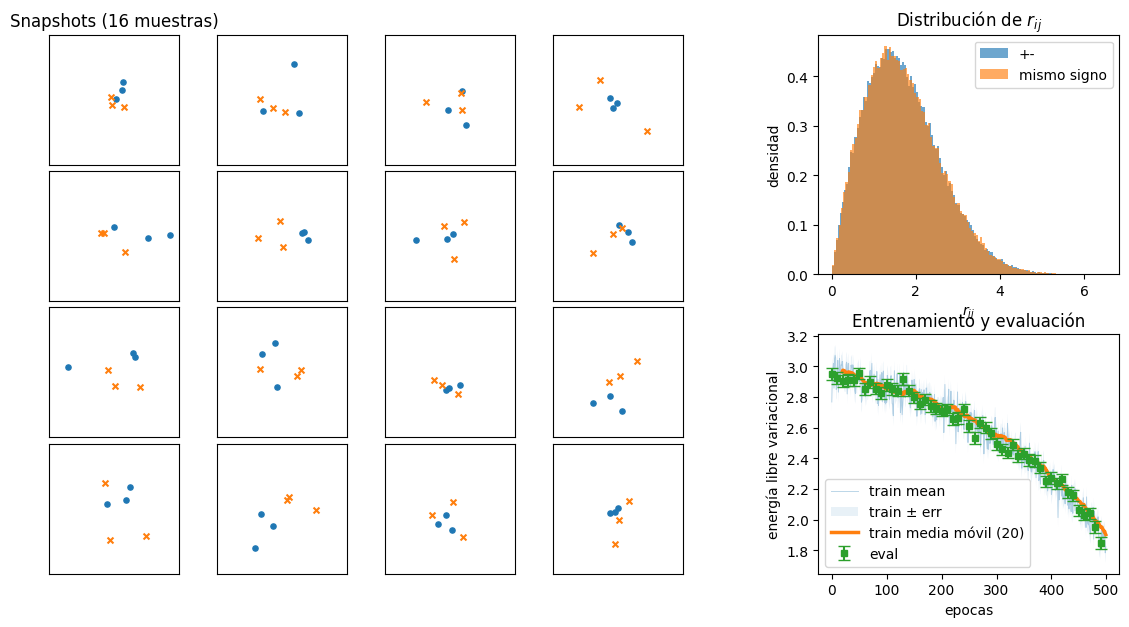

In [29]:
eval_every = 10
eval_batchsize = 50000
smooth_window = 20

loss_history = []
eval_history = []
diag_history = []

for i in range(500):
    step_rng, rng = jax.random.split(rng)
    
    value, aux, opt_state, gnorm, gscale = step(step_rng, i, opt_state)

    f_mean, f_err, e_mean, logq_mean, x = aux

    rmin, r_eff_min, rmed, frac_005, frac_010 = pair_distance_stats(x, n, dim, lj_soft=0.10)

    loss_history.append([float(f_mean), float(f_err)])
    diag_history.append([i, float(rmin), float(r_eff_min), float(rmed), float(frac_005), float(frac_010)])

    eval_mean, eval_err = None, None
    eval_e_mean, eval_logq_mean = None, None
    

    if i % eval_every == 0:
        eval_rng, rng = jax.random.split(rng)
        params = get_params(opt_state)
        eval_mean, eval_err, eval_e_mean, eval_logq_mean,rq50, rq90, rq99, rmax, emax, _ = evaluate(params, eval_rng, eval_batchsize)
        eval_history.append([i, float(eval_mean), float(eval_err)])

    display.clear_output(wait=True)

    print(
        f"iter={i} | train_f={float(f_mean):.6f} ± {float(f_err):.6f} "
        f"| E={float(e_mean):.6f} | logq={float(logq_mean):.6f} "
        f"| rmin={float(rmin):.6f} | r_eff_min={float(r_eff_min):.6f} | rmed={float(rmed):.6f} "
        f"| frac<0.05={float(frac_005):.6e} | frac<0.10={float(frac_010):.6e}"
        f"| grad_norm={float(gnorm):.6f}"
        f"| grad_scale={float(gscale):.6f}"
        f"| rq50={float(rq50):.6f} | rq90={float(rq90):.6f} | rq99={float(rq99):.6f} | rmax={float(rmax):.6f}| emax={float(emax):.6f}"

    )

    if eval_mean is not None:
        print(
            f"          eval_f={float(eval_mean):.6f} ± {float(eval_err):.6f} "
            f"| eval_E={float(eval_e_mean):.6f} | eval_logq={float(eval_logq_mean):.6f}"
        )
    X = np.array(x).reshape(batchsize, n, dim)

    display.clear_output(wait=True)

    fig = plt.figure(figsize=(14, 7))
    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        width_ratios=[2.2, 1.0],
        height_ratios=[1.0, 1.0],
        wspace=0.25, hspace=0.25
    )
    # =========================
    # (1) Snapshots 4x4 (solo cada viz_every)
    # =========================
    subgs = gs[:, 0].subgridspec(4, 4, wspace=0.05, hspace=0.05)

    if (i % viz_every) == 0:
        idx = np.random.choice(batchsize, 16, replace=False)
    else:
        # para no recalcular snapshots todo el tiempo, reutiliza índices deterministas
        rng_np = np.random.default_rng(i)
        idx = rng_np.choice(batchsize, 16, replace=False)

    for k, sidx in enumerate(idx):
        ax = fig.add_subplot(subgs[k // 4, k % 4])
        ax.scatter(X[sidx, pos_mask, 0], X[sidx, pos_mask, 1], s=14, marker='o')
        ax.scatter(X[sidx, neg_mask, 0], X[sidx, neg_mask, 1], s=18, marker='x')
        ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim])
        ax.set_aspect('equal', adjustable='box')
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_title("Snapshots (16 muestras)")

    # =========================
    # (2) Histograma de r_ij por tipo de par 
    # =========================
    ax_r = fig.add_subplot(gs[0, 1])

    d = X[:, iu[0], :] - X[:, iu[1], :]                 # (batch, n_pairs, dim)
    rij = np.linalg.norm(d, axis=-1)                    # (batch, n_pairs)

    qq_pairs = (q_np[iu[0]] * q_np[iu[1]])              # (n_pairs,)
    rij_pm = rij[:, qq_pairs == -1].ravel()             # +-
    rij_ss = rij[:, qq_pairs == +1].ravel()             # mismo signo (++, --)

    ax_r.hist(rij_pm, bins=120, density=True, alpha=0.65, label='+-')
    ax_r.hist(rij_ss, bins=120, density=True, alpha=0.65, label='mismo signo')
    ax_r.set_xlabel(r"$r_{ij}$")
    ax_r.set_ylabel("densidad")
    ax_r.set_title(r"Distribución de $r_{ij}$")
    ax_r.legend()

    # =========================
    # panel de entrenamiento/evaluación
    # =========================
    ax_f = fig.add_subplot(gs[1, 1])
    y = np.array(loss_history)
    train_means = y[:, 0]
    train_errs = y[:, 1]
    t = np.arange(len(train_means))

    #train linea tenue mas mean+-err
    ax_f.plot(
         t,
         train_means,
         alpha=0.3,
         linewidth=0.7,
         label='train mean'
     )
    ax_f.fill_between(
        t,
        train_means - train_errs,
        train_means + train_errs,
        alpha=0.1,
        label = 'train ± err'
    )
     

    # media móvil (20)
    smooth_window = 20
    if len(train_means) >= smooth_window:
        smooth = np.convolve(train_means, np.ones(smooth_window) / smooth_window, mode='valid')
        ax_f.plot(
            np.arange(smooth_window - 1, len(train_means)),
            smooth,
            linewidth=2.5,
            label=f'train media móvil ({smooth_window})'
        )

    # eval points (si los guardas en eval_history como antes)
    if len(eval_history) > 0:
        e = np.array(eval_history)
        eval_iters = e[:, 0]
        eval_means = e[:, 1]
        eval_errs = e[:, 2]
        ax_f.errorbar(
            eval_iters,
            eval_means,
            yerr=eval_errs,
            fmt='s',
            markersize=5,
            capsize=4,
            linewidth=1.5,
            label='eval'
        )

    ax_f.set_xlabel('epocas')
    ax_f.set_ylabel('energía libre variacional')
    ax_f.set_title('Entrenamiento y evaluación')
    ax_f.legend()

    plt.tight_layout()
    plt.pause(0.01)



# energía del sistema despues de la optimmización.


In [30]:
sample_realnvp = x.reshape(batchsize, n, dim)
energy_realnvp = vmap(energy_wrapped, (0, None, None), 0)(sample_realnvp, n, dim)
print(jnp.mean(energy_realnvp), jnp.std(energy_realnvp)/jnp.sqrt(batchsize))

213.00458371814508 0.051336322926561546


# MCMC 

In [31]:
@partial(jit, static_argnums=0)
def mcmc(logp_fn, x_init, key, mc_steps, mc_width):
    """
        Markov Chain Monte Carlo sampling algorithm.

    INPUT:
        logp_fn: callable that evaluate log-probability of a batch of configuration x.
            The signature is logp_fn(x), where x has shape (batch, n, dim).
        x_init: initial value of x, with shape (batch, n, dim).
        key: initial PRNG key.
        mc_steps: total number of Monte Carlo steps.
        mc_width: size of the Monte Carlo proposal.

    OUTPUT:
        x: resulting batch samples, with the same shape as `x_init`.
    """
    def step(i, state):
        x, logp, key, num_accepts = state
        key, key_proposal, key_accept = jax.random.split(key, 3)
        
        x_proposal = x + mc_width * jax.random.normal(key_proposal, x.shape)
        logp_proposal = logp_fn(x_proposal)

        ratio = jnp.exp((logp_proposal - logp))
        accept = jax.random.uniform(key_accept, ratio.shape) < ratio

        x_new = jnp.where(accept[:, None, None], x_proposal, x)
        logp_new = jnp.where(accept, logp_proposal, logp)
        num_accepts += accept.sum()
        return x_new, logp_new, key, num_accepts
    
    logp_init = logp_fn(x_init)

    x, logp, key, num_accepts = jax.lax.fori_loop(0, mc_steps, step, (x_init, logp_init, key, 0.))
    batch = x.shape[0]
    accept_rate = num_accepts / (mc_steps * batch)
    return x, accept_rate

In [32]:
@partial(jax.vmap, in_axes=(None, 0, None, None))
def logp(beta, x, n, dim):
    return -beta * energy_wrapped(x, n, dim)

In [33]:
mc_steps = 100 
mc_width = 0.05

init_rng, rng = random.split(rng)

x = random.normal(init_rng, (batchsize, n, dim))

for _ in range(20):
    mcmc_rng, rng = random.split(rng)
    x, acc = mcmc(lambda x: logp(beta, x, n, dim), x, mcmc_rng, mc_steps, mc_width)
    e = vmap(energy_wrapped, (0, None, None), 0)(x, n, dim)
    print (acc, jnp.mean(e), jnp.std(e)/jnp.sqrt(batchsize))


0.418354375 200.56256600428102 0.04583082322828633
0.1973075 195.2240724180898 0.039613468059358316
0.100369375 192.53710032465335 0.03672729662477225
0.071529375 190.90347855626675 0.03448346235076933
0.05859875 189.66064542776434 0.03123600480590939
0.048339375 188.72598323518366 0.027734299526355838
0.0407975 188.00283493007663 0.02436579697662571
0.0343375 187.47263579861294 0.021392488914036688
0.029739375 187.062945351647 0.018857787796398302
0.026185 186.73576230774125 0.016653214218749872
0.02333375 186.48437559693494 0.01485863183118164
0.020919375 186.27773230126547 0.013356108931609616
0.019056875 186.11622848424057 0.012089570479722563
0.017830625 185.97493808414526 0.01099280337155697
0.0166375 185.8578427064215 0.009983992265977439
0.01550375 185.76796226891824 0.009173398688255157
0.014993125 185.68824973082084 0.008459563314471024
0.014190625 185.62710111627237 0.00790630192569588
0.013861875 185.56932735381088 0.007411291319911427
0.01366375 185.52479093798098 0.007005

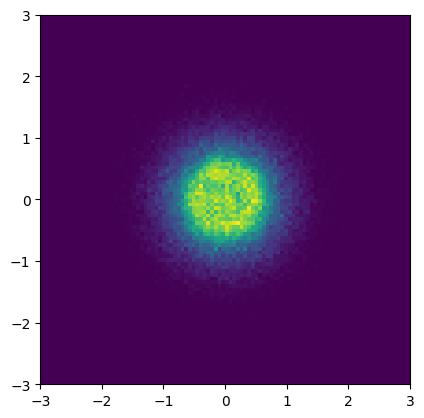

In [34]:
x = jnp.reshape(x, (batchsize*n, dim)) 
#density plot
H, xedges, yedges = np.histogram2d(x[:, 0], x[:, 1], 
                                       bins=100, 
                                       range=((-3, 3), (-3, 3)),
                        density=True)

plt.imshow(H, interpolation="nearest", 
               extent=(xedges[0], xedges[-1], yedges[0], yedges[-1]),
               cmap="viridis")


# Optimizando la energía del estado base

In [35]:
energy_rng, rng = random.split(rng)
x_init = jax.random.normal(energy_rng, (n, dim))

energy_and_grad = jax.value_and_grad(energy_fun)

opt_init, opt_update, get_params = optimizers.adam(step_size=1e-4)
opt_state = opt_init(x_init)

In [36]:
def energy_optimize(rng, i, opt_state):
    x_new = get_params(opt_state)
    energy, grad = energy_and_grad(x_new, n, dim, q = q, k_trap=1.0, k_coul=1.0, lj_eps=0.1, lj_sigma=0.12, lj_soft=0.05, use_wca=True, a_coul=0.10)

    opt_state = opt_update(i, grad, opt_state)
    return energy, opt_state, x_new

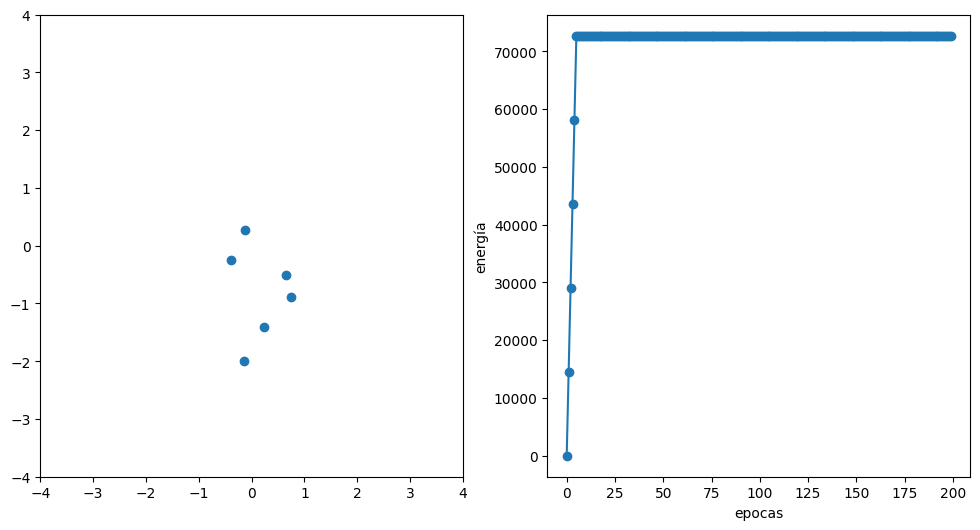

72721.45587166793


In [37]:
energy_history = []
for i in range(200):
    step_rng, rng = jax.random.split(rng)
    value, opt_state, x = energy_optimize(step_rng, i, opt_state)

    energy_history.append([value])

    display.clear_output(wait=True)

    fig = plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(x[:, 0], x[:, 1])

    plt.xlim([-4, 4])
    plt.ylim([-4, 4])

    plt.subplot(1, 2, 2)
    y = np.array(energy_history)
    plt.errorbar(np.arange(i+1), y, marker='o', capsize=8)
    plt.xlabel('epocas')
    plt.ylabel('energía')
    plt.pause(0.01)

print(value)

# Colapso del modelo sin un núcleo repulsivo 

Al intentar optimizar la enregía del el estado base del sistema, en r cuando se va a 0 algunas partículas comienzan a intentar ocupar el mismo sitio por atracción, y la energía se va a menos infinito, es necesario agregar un núcleo repulsivo o inicializar las particulas estando separadas con un penalización para efvitar que esto ocurra